In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
import numpy as np
import matplotlib.pyplot as plt
 
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier


# 0 = real, 1 = fake

***first, original WELFake dataset***

In [2]:
df = pd.read_csv('WELFake.csv')
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [3]:
# drop first column
df = df.drop(df.columns[0], axis=1)
df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [4]:
# count how many are null
df.isna().sum()

title    558
text      39
label      0
dtype: int64

In [5]:
df = df.dropna()
df.isna().sum()

title    0
text     0
label    0
dtype: int64

dropped 597 null rows

In [6]:
# sanity check
df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1


In [7]:
# clean the texts
def clean(col):
    res = []
    for text in col:
        text = text.lower()
        text = re.sub(r'[^a-z\s]', '', text)
        tokens = word_tokenize(text) # separate each word
        lemmatized = [lemmatizer.lemmatize(word) for word in tokens
                      if len(word)] # turn into root/main word
        filtered = [word for word in lemmatized if word not in stop_words]
        res.append(' '.join(filtered))
        
    return res

df['title_cleaned'] = clean(df['title'])
df['text_cleaned'] = clean(df['text'])

In [8]:
df.head()

,title,text,label,title_cleaned,text_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforcement high alert following threat co...,comment expected barack obama member fyf fukyo...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbelievable obamas attorney general say charl...,demonstrator gathered last night exercising co...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,bobby jindal raised hindu us story christian c...,dozen politically active pastor came private d...
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan russia unvelis image terrifying new supe...,r sarmat missile dubbed satan replace fly mile...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,time christian group sue amazon splc designati...,say one time someone sued southern poverty law...


In [9]:
# feature engineering

def add_cols(df):
    df['title_length'] = df['title'].str.split().str.len()
    df['text_length'] = df['text'].str.split().str.len()  
    
    df['title_excl'] = df['title'].str.count('!')
    df['text_excl'] = df['text'].str.count('!')
    
    df['title_sentiment'] = df['title'].apply(lambda x: TextBlob(x).sentiment.polarity)
    df['text_sentiment'] = df['text'].apply(lambda x: TextBlob(x).sentiment.polarity)
    
    df['title_subjectivity'] = df['title'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
    df['text_subjectivity'] = df['text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
    
    df['clickbait_score'] = abs((df['title_subjectivity'] + df['title_sentiment']) / 2)

    return df

df.head()

,title,text,label,title_cleaned,text_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforcement high alert following threat co...,comment expected barack obama member fyf fukyo...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbelievable obamas attorney general say charl...,demonstrator gathered last night exercising co...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,bobby jindal raised hindu us story christian c...,dozen politically active pastor came private d...
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan russia unvelis image terrifying new supe...,r sarmat missile dubbed satan replace fly mile...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,time christian group sue amazon splc designati...,say one time someone sued southern poverty law...


In [10]:
# apply to first dataset
df = add_cols(df)
df.head()

,title,text,label,title_cleaned,text_cleaned,title_length,text_length,title_excl,text_excl,title_sentiment,text_sentiment,title_subjectivity,text_subjectivity,clickbait_score
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforcement high alert following threat co...,comment expected barack obama member fyf fukyo...,18,871,0,2,0.080000,0.033103,0.320000,0.296038,0.200000
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbelievable obamas attorney general say charl...,demonstrator gathered last night exercising co...,18,34,1,0,0.121875,0.258929,0.625000,0.400595,0.373437
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,bobby jindal raised hindu us story christian c...,dozen politically active pastor came private d...,16,1321,0,0,0.000000,0.113865,0.500000,0.384704,0.250000
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan russia unvelis image terrifying new supe...,r sarmat missile dubbed satan replace fly mile...,16,329,0,0,-0.287879,0.056373,0.484848,0.391967,0.098485
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,time christian group sue amazon splc designati...,say one time someone sued southern poverty law...,13,244,1,1,-0.400000,-0.079803,0.450000,0.427094,0.025000


quick dataset description:

polarity sentiment ranges from -1 to 1:

    -1 = negative sentiment, 1 = positive sentiment

subjectivity ranges from 0 to 1:

    0 = objective statement, 1 = subjective statement

0 is ideal for news articles. Neutral and objective.

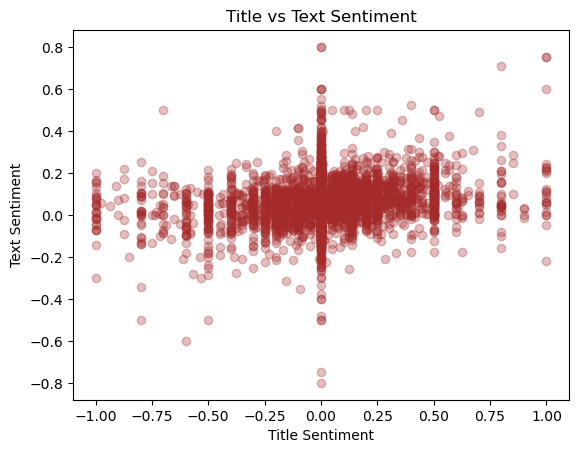

In [11]:
# sample plot for milestone
sample = df.sample(5000, random_state=42)

plt.scatter(sample['title_sentiment'], sample['text_sentiment'], alpha=0.3, color='brown')
plt.xlabel('Title Sentiment')
plt.ylabel('Text Sentiment')
plt.title('Title vs Text Sentiment')
plt.show()

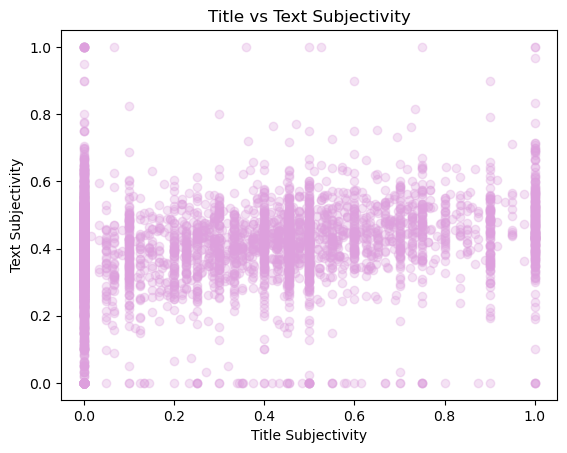

In [12]:
# sample plot for milestone
sample = df.sample(5000, random_state=42)

plt.scatter(sample['title_subjectivity'], sample['text_subjectivity'], alpha=0.3, color='plum')
plt.xlabel('Title Subjectivity')
plt.ylabel('Text Subjectivity')
plt.title('Title vs Text Subjectivity')
plt.show()

In [13]:
# tf idf, keep 1000 words. the most efficient time wise
tfidf_title = TfidfVectorizer(max_features=1000)
tfidf_text = TfidfVectorizer(max_features=1000)

title_tfidf = tfidf_title.fit_transform(df['title_cleaned'])
text_tfidf = tfidf_text.fit_transform(df['text_cleaned'])

In [14]:
# featured columns for the analysis are all the ones I calculated
featured_cols = [c for c in df.columns if c.endswith(('_length', '_excl', '_sentiment', '_subjectivity', '_score'))]

# just numbers matrix
num_matrix = df[featured_cols].values

# combine columns
X = hstack([title_tfidf, text_tfidf, csr_matrix(num_matrix)])
y = df['label']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**logistic regression**

In [16]:
# logistic regression
lr = LogisticRegression(max_iter=5000, random_state=42)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [17]:
def metrics(y_true, y_pred):
    error = round(1 - accuracy_score(y_true, y_pred), 4)
    acc = round(accuracy_score(y_true, y_pred), 4)
    precision = round(precision_score(y_true, y_pred), 4)
    recall = round(recall_score(y_true, y_pred), 4)
    f1 = round(f1_score(y_true, y_pred), 4)
    auc = float(round(roc_auc_score(y_true, y_pred), 4))

    metrics = {
    'Error': error,
    'Accuracy': acc,
    'Precision': precision,
    'Recall': recall,
    'f1': f1,
    'AUC': auc
    }

    return metrics

In [18]:
lr_metrics = metrics(y_test, lr_pred)
lr_metrics

{'Error': 0.0388,
 'Accuracy': 0.9612,
 'Precision': 0.958,
 'Recall': 0.9655,
 'f1': 0.9618,
 'AUC': 0.9612}

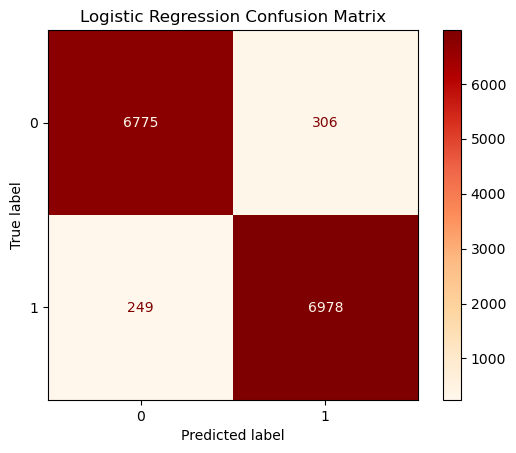

In [19]:
cm_lr = ConfusionMatrixDisplay.from_predictions(y_test,lr_pred, cmap='OrRd')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

**kNN**

In [20]:
# knn for different values
k_vals = [7, 9, 11, 13, 15, 21]

for k in k_vals:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    knn_pred = knn.predict(X_test)
    print(f"k={k}")
    
    knn_metrics = metrics(y_test, knn_pred)
    print(knn_metrics)

# tried [5, 7, 15, 21] at first

k=7
{'Error': 0.2448, 'Accuracy': 0.7552, 'Precision': 0.7917, 'Recall': 0.6995, 'f1': 0.7427, 'AUC': 0.7558}
k=9
{'Error': 0.2458, 'Accuracy': 0.7542, 'Precision': 0.7978, 'Recall': 0.6876, 'f1': 0.7386, 'AUC': 0.7549}
k=11
{'Error': 0.2463, 'Accuracy': 0.7537, 'Precision': 0.8021, 'Recall': 0.6802, 'f1': 0.7361, 'AUC': 0.7545}
k=13
{'Error': 0.2449, 'Accuracy': 0.7551, 'Precision': 0.8078, 'Recall': 0.6759, 'f1': 0.736, 'AUC': 0.7559}
k=15
{'Error': 0.2456, 'Accuracy': 0.7544, 'Precision': 0.8086, 'Recall': 0.673, 'f1': 0.7346, 'AUC': 0.7552}
k=21
{'Error': 0.2516, 'Accuracy': 0.7484, 'Precision': 0.8091, 'Recall': 0.6568, 'f1': 0.7251, 'AUC': 0.7493}


k=7 is best

In [22]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_metrics = metrics(y_test, knn_pred)
knn_metrics

{'Error': 0.2448,
 'Accuracy': 0.7552,
 'Precision': 0.7917,
 'Recall': 0.6995,
 'f1': 0.7427,
 'AUC': 0.7558}

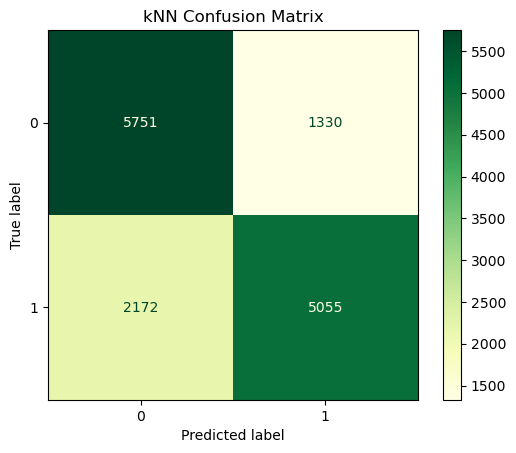

In [23]:
cm_knn = ConfusionMatrixDisplay.from_predictions(y_test,knn_pred, cmap='YlGn')
plt.title('kNN Confusion Matrix')
plt.show()

**LDA**

In [24]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train.toarray(), y_train) # typeError told me to convert to array

lda_pred = lda.predict(X_test.toarray())

lda_metrics = metrics(y_test, lda_pred)
lda_metrics

{'Error': 0.0435,
 'Accuracy': 0.9565,
 'Precision': 0.9469,
 'Recall': 0.968,
 'f1': 0.9574,
 'AUC': 0.9563}

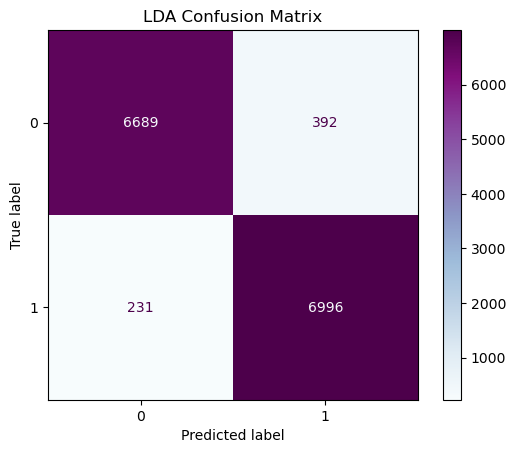

In [25]:
cm_lda = ConfusionMatrixDisplay.from_predictions(y_test,lda_pred, cmap='BuPu')
plt.title('LDA Confusion Matrix')
plt.show()

**MLP**

In [26]:
# trying different hidden layers numbers
mlp_1 = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
mlp_1.fit(X_train, y_train)

mlp_pred_1 = mlp_1.predict(X_test)

mlp_metrics_1 = metrics(y_test, mlp_pred_1)
mlp_metrics_1

{'Error': 0.0326,
 'Accuracy': 0.9674,
 'Precision': 0.9633,
 'Recall': 0.9726,
 'f1': 0.9679,
 'AUC': 0.9674}

In [27]:
# more hidden layers
mlp_2 = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)
mlp_2.fit(X_train, y_train)

mlp_pred_2 = mlp_2.predict(X_test)

mlp_metrics_2 = metrics(y_test, mlp_pred_2)
mlp_metrics_2

{'Error': 0.0368,
 'Accuracy': 0.9632,
 'Precision': 0.951,
 'Recall': 0.9776,
 'f1': 0.9641,
 'AUC': 0.9631}

mlp_1 is better because it's better on every single metric. f1 is very important here for the balance. not that much of a difference though.

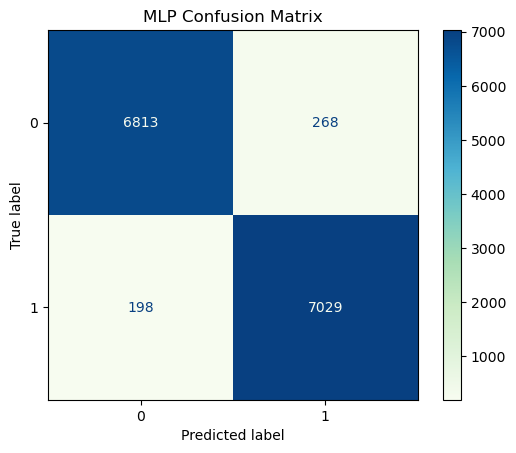

In [28]:
cm_mlp = ConfusionMatrixDisplay.from_predictions(y_test,mlp_pred_1, cmap='GnBu')
plt.title('MLP Confusion Matrix')
plt.show()

**comparing the different results**

In [29]:
results = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'kNN': knn_metrics,
    'LDA': lda_metrics,
    'MLP': mlp_metrics_1
})

results

,Logistic Regression,kNN,LDA,MLP
Error,0.0388,0.2448,0.0435,0.0326
Accuracy,0.9612,0.7552,0.9565,0.9674
Precision,0.9580,0.7917,0.9469,0.9633
Recall,0.9655,0.6995,0.9680,0.9726
f1,0.9618,0.7427,0.9574,0.9679
AUC,0.9612,0.7558,0.9563,0.9674


In [30]:
# dropping error for the visualizations
results = results.drop('Error')

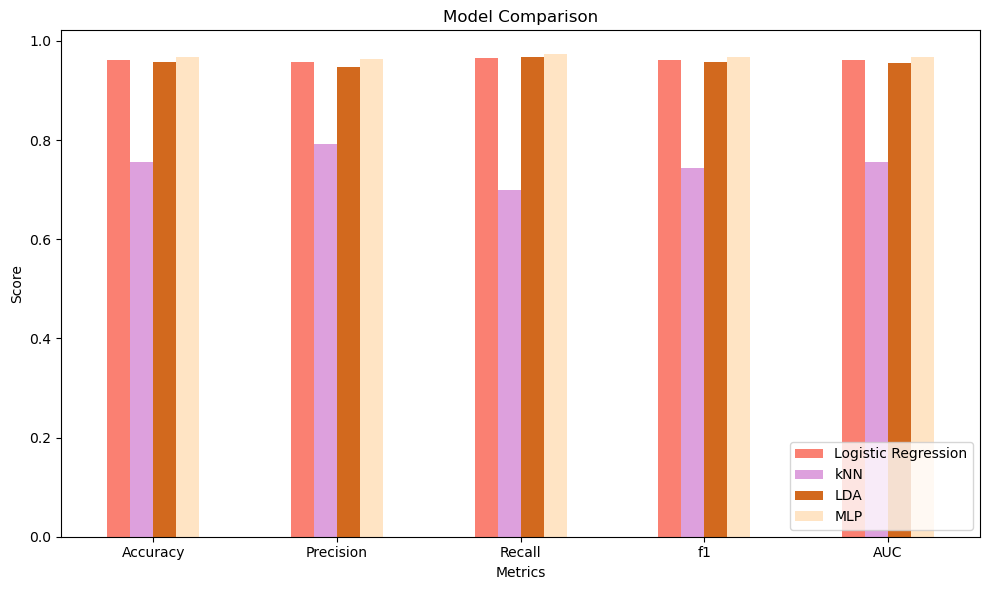

In [31]:
results.plot(kind='bar', figsize=(10, 6), color=['salmon','plum', 'chocolate', 'bisque'])
plt.title('Model Comparison')
plt.xlabel('Metrics')
plt.xticks(rotation=0)
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()

**roc curve**

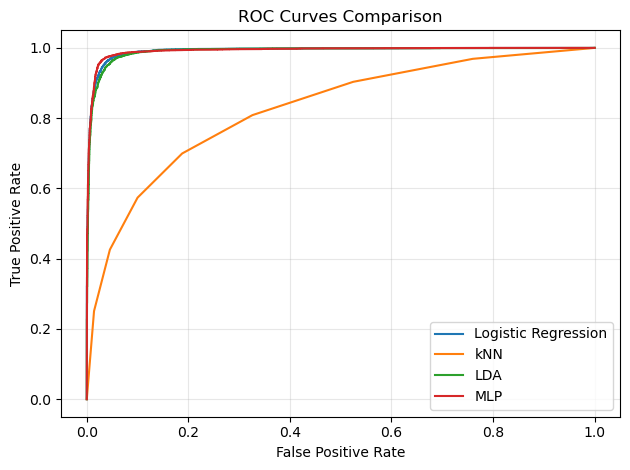

In [32]:
lr_proba = lr.predict_proba(X_test)[:, 1]
knn_proba = knn.predict_proba(X_test)[:, 1]
lda_proba = lda.predict_proba(X_test.toarray())[:, 1]
mlp_proba = mlp_1.predict_proba(X_test)[:, 1]

for name, proba in [('Logistic Regression', lr_proba), ('kNN', knn_proba), ('LDA', lda_proba), ('MLP', mlp_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=name)

        
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('roc_curves.png')
plt.show()

***testing my models on a new, but smaller dataset***

In [33]:
news = pd.read_csv('news_articles.csv')
news.head()

,author,published,title,text,language,site_url,main_img_url,type,label,title_without_stopwords,text_without_stopwords,hasImage
0,Barracuda Brigade,2016-10-26T21:41:00.000+03:00,muslims busted they stole millions in govt ben...,print they should pay all the back all the mon...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,muslims busted stole millions govt benefits,print pay back money plus interest entire fami...,1.0
1,reasoning with facts,2016-10-29T08:47:11.259+03:00,re why did attorney general loretta lynch plea...,why did attorney general loretta lynch plead t...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,attorney general loretta lynch plead fifth,attorney general loretta lynch plead fifth bar...,1.0
2,Barracuda Brigade,2016-10-31T01:41:49.479+02:00,breaking weiner cooperating with fbi on hillar...,red state \nfox news sunday reported this mor...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,breaking weiner cooperating fbi hillary email ...,red state fox news sunday reported morning ant...,1.0
3,Fed Up,2016-11-01T05:22:00.000+02:00,pin drop speech by father of daughter kidnappe...,email kayla mueller was a prisoner and torture...,english,100percentfedup.com,http://100percentfedup.com/wp-content/uploads/...,bias,Real,pin drop speech father daughter kidnapped kill...,email kayla mueller prisoner tortured isis cha...,1.0
4,Fed Up,2016-11-01T21:56:00.000+02:00,fantastic trumps point plan to reform healthc...,email healthcare reform to make america great ...,english,100percentfedup.com,http://100percentfedup.com/wp-content/uploads/...,bias,Real,fantastic trumps point plan reform healthcare ...,email healthcare reform make america great sin...,1.0


In [34]:
# drop null
news = news.dropna()

# keeping only the same cols as from the original dataset
news = news[['title', 'text', 'label']]
news.head()

,title,text,label
0,muslims busted they stole millions in govt ben...,print they should pay all the back all the mon...,Real
1,re why did attorney general loretta lynch plea...,why did attorney general loretta lynch plead t...,Real
2,breaking weiner cooperating with fbi on hillar...,red state \nfox news sunday reported this mor...,Real
3,pin drop speech by father of daughter kidnappe...,email kayla mueller was a prisoner and torture...,Real
4,fantastic trumps point plan to reform healthc...,email healthcare reform to make america great ...,Real


In [35]:
# data was already somewhat preprocessed, i chose to keep the columns with stopwords just so the preprocessing is more similar
# applying the same cleaning
news['title_cleaned'] = clean(news['title'])
news['text_cleaned'] = clean(news['text'])

# encode label
news['label'] = news['label'].map({'Real': 0, 'Fake': 1})
news.head()

,title,text,label,title_cleaned,text_cleaned
0,muslims busted they stole millions in govt ben...,print they should pay all the back all the mon...,0,muslim busted stole million govt benefit,print pay back money plus interest entire fami...
1,re why did attorney general loretta lynch plea...,why did attorney general loretta lynch plead t...,0,attorney general loretta lynch plead fifth,attorney general loretta lynch plead fifth bar...
2,breaking weiner cooperating with fbi on hillar...,red state \nfox news sunday reported this mor...,0,breaking weiner cooperating fbi hillary email ...,red state fox news sunday reported morning ant...
3,pin drop speech by father of daughter kidnappe...,email kayla mueller was a prisoner and torture...,0,pin drop speech father daughter kidnapped kill...,email kayla mueller wa prisoner tortured isi c...
4,fantastic trumps point plan to reform healthc...,email healthcare reform to make america great ...,0,fantastic trump point plan reform healthcare b...,email healthcare reform make america great sin...


In [36]:
# feature engineering from earlier
# the exclamation point count will still be added so the dimensions are the same
# but they will be zeros so they won't affect anything

news = add_cols(news)
news.head()

,title,text,label,title_cleaned,text_cleaned,title_length,text_length,title_excl,text_excl,title_sentiment,text_sentiment,title_subjectivity,text_subjectivity,clickbait_score
0,muslims busted they stole millions in govt ben...,print they should pay all the back all the mon...,0,muslim busted stole million govt benefit,print pay back money plus interest entire fami...,8,86,0,0,0.00,0.100000,0.0,0.405000,0.000
1,re why did attorney general loretta lynch plea...,why did attorney general loretta lynch plead t...,0,attorney general loretta lynch plead fifth,attorney general loretta lynch plead fifth bar...,10,273,0,0,0.05,0.042381,0.5,0.368254,0.275
2,breaking weiner cooperating with fbi on hillar...,red state \nfox news sunday reported this mor...,0,breaking weiner cooperating fbi hillary email ...,red state fox news sunday reported morning ant...,9,222,0,0,0.00,0.183000,0.0,0.533667,0.000
3,pin drop speech by father of daughter kidnappe...,email kayla mueller was a prisoner and torture...,0,pin drop speech father daughter kidnapped kill...,email kayla mueller wa prisoner tortured isi c...,20,48,0,0,-0.20,-0.066667,0.0,0.916667,0.100
4,fantastic trumps point plan to reform healthc...,email healthcare reform to make america great ...,0,fantastic trump point plan reform healthcare b...,email healthcare reform make america great sin...,12,327,0,0,0.40,0.176472,0.9,0.448784,0.650


In [37]:
# tf idf again, but this time transform only
news_title_tfidf = tfidf_title.transform(news['title_cleaned'])
news_text_tfidf = tfidf_text.transform(news['text_cleaned'])

news_nm = news[featured_cols].values
news_X = hstack([news_title_tfidf, news_text_tfidf, csr_matrix(news_nm)])
news_y = news['label']

In [38]:
# logistic regression
lr_news_pred = lr.predict(news_X)
lr_news_metrics = metrics(news_y, lr_news_pred)

# kNN
knn_news_pred = knn.predict(news_X)
knn_news_metrics = metrics(news_y, knn_news_pred)

#LDA
lda_news_pred = lda.predict(news_X.toarray())
lda_news_metrics = metrics(news_y, lda_news_pred)

# mlp neural network
mlp_news_pred = mlp_1.predict(news_X)
mlp_news_metrics = metrics(news_y, mlp_news_pred)

In [39]:
res_news = pd.DataFrame({
    'Logistic Regression': lr_news_metrics,
    'kNN': knn_news_metrics,
    'LDA': lda_news_metrics,
    'MLP': mlp_news_metrics
})

res_news

,Logistic Regression,kNN,LDA,MLP
Error,0.3638,0.4641,0.3604,0.3741
Accuracy,0.6362,0.5359,0.6396,0.6259
Precision,0.6466,0.6619,0.6463,0.6400
Recall,0.9342,0.5414,0.9481,0.9311
f1,0.7643,0.5957,0.7686,0.7586
AUC,0.5301,0.5340,0.5298,0.5173


In [40]:
# accuracies for each model in the original data
df_acc = [lr_metrics['Accuracy'], knn_metrics['Accuracy'], lda_metrics['Accuracy'], mlp_metrics_1['Accuracy']]

# accuracies for each model in the newer data
news_acc = [lr_news_metrics['Accuracy'], knn_news_metrics['Accuracy'], lda_news_metrics['Accuracy'], mlp_news_metrics['Accuracy']]

models = ['Log. Reg', 'kNN', 'LDA', 'MLP']

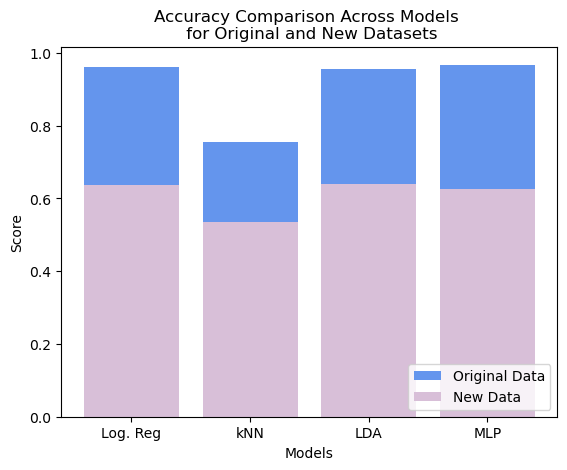

In [41]:
plt.bar(models, df_acc, label='Original Data', color='cornflowerblue')
plt.bar(models, news_acc, label='New Data', color='thistle')
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Accuracy Comparison Across Models \n for Original and New Datasets')
plt.legend(loc='lower right')
plt.show()

In [48]:
# which coefficients mattered the most?

def get_coefs(model):
    coef = len(featured_cols)
    eng_coefs = model.coef_[0][-coef:]
    
    coef_df = pd.DataFrame({'Feature': featured_cols, 'Coefficient': eng_coefs}).sort_values('Coefficient', ascending=False)
    return coef_df

In [49]:
lr_coefs = get_coefs(lr)
lr_coefs

,Feature,Coefficient
2,title_excl,2.131700
7,text_subjectivity,1.263077
8,clickbait_score,0.288302
3,text_excl,0.198740
0,title_length,0.166691
6,title_subjectivity,0.162011
1,text_length,-0.000062
5,text_sentiment,-0.181196
4,title_sentiment,-0.395971


In [50]:
lda_coefs = get_coefs(lda)
lda_coefs

,Feature,Coefficient
2,title_excl,0.969062
7,text_subjectivity,0.765398
8,clickbait_score,0.538246
0,title_length,0.268632
3,text_excl,0.113204
6,title_subjectivity,0.049664
1,text_length,0.000026
5,text_sentiment,-0.253451
4,title_sentiment,-0.571067


In [52]:
# perm importance for MLP

from sklearn.inspection import permutation_importance

eng_cols = len(featured_cols)

result = permutation_importance(mlp_1, X_test.toarray(), y_test, n_repeats=10, random_state=42)

# grab only the engineered features (last n_eng)
eng_importances = result.importances_mean[-eng_cols:]

imp_df = pd.DataFrame({'Feature': featured_cols, 'Importance': eng_importances}).sort_values('Importance', ascending=False)
imp_df

,Feature,Importance
1,text_length,0.023903
0,title_length,0.014768
3,text_excl,0.005417
2,title_excl,0.003781
4,title_sentiment,0.000629
7,text_subjectivity,0.000489
6,title_subjectivity,0.000238
5,text_sentiment,0.000189
8,clickbait_score,0.000168
